In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt
from itertools import permutations

# Define the 20x20 Distance Matrix (from Nugent - homework document)
# This is a symmetric distance matrix
distance_matrix = np.array([
    [0, 1, 2, 3, 4, 1, 2, 3, 4, 5, 2, 3, 4, 5, 6, 3, 4, 5, 6, 7],
    [1, 0, 1, 2, 3, 2, 1, 2, 3, 4, 3, 2, 3, 4, 5, 4, 3, 4, 5, 6],
    [2, 1, 0, 1, 2, 3, 2, 1, 2, 3, 4, 3, 2, 3, 4, 5, 4, 3, 4, 5],
    [3, 2, 1, 0, 1, 4, 3, 2, 1, 2, 5, 4, 3, 2, 3, 6, 5, 4, 3, 4],
    [4, 3, 2, 1, 0, 5, 4, 3, 2, 1, 6, 5, 4, 3, 2, 7, 6, 5, 4, 3],
    [1, 2, 3, 4, 5, 0, 1, 2, 3, 4, 1, 2, 3, 4, 5, 2, 3, 4, 5, 6],
    [2, 1, 2, 3, 4, 1, 0, 1, 2, 3, 2, 1, 2, 3, 4, 3, 2, 3, 4, 5],
    [3, 2, 1, 2, 3, 2, 1, 0, 1, 2, 3, 2, 1, 2, 3, 4, 3, 2, 3, 4],
    [4, 3, 2, 1, 2, 3, 2, 1, 0, 1, 4, 3, 2, 1, 2, 5, 4, 3, 2, 3],
    [5, 4, 3, 2, 1, 4, 3, 2, 1, 0, 5, 4, 3, 2, 1, 6, 5, 4, 3, 2],
    [2, 3, 4, 5, 6, 1, 2, 3, 4, 5, 0, 1, 2, 3, 4, 1, 2, 3, 4, 5],
    [3, 2, 3, 4, 5, 2, 1, 2, 3, 4, 1, 0, 1, 2, 3, 2, 1, 2, 3, 4],
    [4, 3, 2, 3, 4, 3, 2, 1, 2, 3, 2, 1, 0, 1, 2, 3, 2, 1, 2, 3],
    [5, 4, 3, 2, 3, 4, 3, 2, 1, 2, 3, 2, 1, 0, 1, 4, 3, 2, 1, 2],
    [6, 5, 4, 3, 2, 5, 4, 3, 2, 1, 4, 3, 2, 1, 0, 5, 4, 3, 2, 1],
    [3, 4, 5, 6, 7, 2, 3, 4, 5, 6, 1, 2, 3, 4, 5, 0, 1, 2, 3, 4],
    [4, 3, 4, 5, 6, 3, 2, 3, 4, 5, 2, 1, 2, 3, 4, 1, 0, 1, 2, 3],
    [5, 4, 3, 4, 5, 4, 3, 2, 3, 4, 3, 2, 1, 2, 3, 2, 1, 0, 1, 2],
    [6, 5, 4, 3, 4, 5, 4, 3, 2, 3, 4, 3, 2, 1, 2, 3, 2, 1, 0, 1],
    [7, 6, 5, 4, 3, 6, 5, 4, 3, 2, 5, 4, 3, 2, 1, 4, 3, 2, 1, 0]
])

# Define the 20x20 Flow Matrix (from homework document - already symmetric)
# This matrix appears to already be the doubled version
flow_matrix = np.array([
    [0, 0, 5, 0, 5, 2, 10, 3, 1, 5, 5, 5, 0, 0, 5, 4, 4, 0, 0, 1],
    [0, 0, 3, 10, 5, 1, 5, 1, 2, 4, 2, 5, 0, 10, 10, 3, 0, 5, 10, 5],
    [5, 3, 0, 2, 0, 5, 2, 4, 4, 5, 0, 0, 0, 5, 1, 0, 0, 5, 0, 0],
    [0, 10, 2, 0, 1, 0, 5, 2, 1, 0, 10, 2, 2, 0, 2, 1, 5, 2, 5, 5],
    [5, 5, 0, 1, 0, 5, 6, 5, 2, 5, 2, 0, 5, 1, 1, 1, 5, 2, 5, 1],
    [2, 1, 5, 0, 5, 0, 5, 2, 1, 6, 0, 0, 10, 0, 2, 0, 1, 0, 1, 5],
    [10, 5, 2, 5, 6, 5, 0, 0, 0, 0, 5, 10, 2, 2, 5, 1, 2, 1, 0, 10],
    [3, 1, 4, 2, 5, 2, 0, 0, 1, 1, 10, 10, 2, 0, 10, 2, 5, 2, 2, 10],
    [1, 2, 4, 1, 2, 1, 0, 1, 0, 2, 0, 3, 5, 5, 0, 5, 0, 0, 0, 2],
    [5, 4, 5, 0, 5, 6, 0, 1, 2, 0, 5, 5, 0, 5, 1, 0, 0, 5, 5, 2],
    [5, 2, 0, 10, 2, 0, 5, 10, 0, 5, 0, 5, 2, 5, 1, 10, 0, 2, 2, 5],
    [5, 5, 0, 2, 0, 0, 10, 10, 3, 5, 5, 0, 2, 10, 5, 0, 1, 1, 2, 5],
    [0, 0, 0, 2, 5, 10, 2, 2, 5, 0, 2, 2, 0, 2, 2, 1, 0, 0, 0, 5],
    [0, 10, 5, 0, 1, 0, 2, 0, 5, 5, 5, 10, 2, 0, 5, 5, 1, 5, 5, 0],
    [5, 10, 1, 2, 1, 2, 5, 10, 0, 1, 1, 5, 2, 5, 0, 3, 0, 5, 10, 10],
    [4, 3, 0, 1, 1, 0, 1, 2, 5, 0, 10, 0, 1, 5, 3, 0, 0, 0, 2, 0],
    [4, 0, 0, 5, 5, 1, 2, 5, 0, 0, 0, 1, 0, 1, 0, 0, 0, 5, 2, 0],
    [0, 5, 5, 2, 2, 0, 1, 2, 0, 5, 2, 1, 0, 5, 5, 0, 5, 0, 1, 1],
    [0, 10, 0, 5, 5, 1, 0, 2, 0, 5, 2, 2, 0, 5, 10, 2, 2, 1, 0, 6],
    [1, 5, 0, 5, 1, 5, 10, 10, 2, 2, 5, 5, 5, 0, 10, 0, 0, 1, 6, 0]
])

# Function to calculate the cost of a given assignment
def calculate_cost(assignment, flow, distance):
    """
    Calculate the total cost for a given assignment.
    Cost = sum over all i,j of Flow[i][j] * Distance[assignment[i]][assignment[j]]
    
    Args:
        assignment: list/array representing facility-to-location assignment
        flow: flow matrix
        distance: distance matrix
    
    Returns:
        total cost
    """
    n = len(assignment)
    cost = 0
    for i in range(n):
        for j in range(n):
            cost += flow[i][j] * distance[assignment[i]][assignment[j]]
    return cost

print("Libraries imported and helper functions defined.")
print(f"Distance matrix shape: {distance_matrix.shape}")
print(f"Flow matrix shape: {flow_matrix.shape}")
print(f"Known optimal cost (with doubled flows): 2570")

Libraries imported and helper functions defined.
Distance matrix shape: (20, 20)
Flow matrix shape: (20, 20)
Known optimal cost (with doubled flows): 2570


In [2]:
def aco_qap(flow, distance, num_ants=20, alpha=1.0, beta=2.0, rho=0.1, Q=100, 
            iterations=100, seed=None):
    """
    Ant Colony Optimization for Quadratic Assignment Problem.
    
    Args:
        flow: flow matrix
        distance: distance matrix
        num_ants: number of ants
        alpha: pheromone importance
        beta: heuristic importance
        rho: evaporation rate
        Q: pheromone deposit factor
        iterations: number of iterations
        seed: random seed for reproducibility
    
    Returns:
        best_assignment: best solution found
        best_cost: cost of best solution
        cost_history: list of best costs per iteration
    """
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)
    
    n = len(flow)
    
    # Initialize pheromone matrix (n x n)
    pheromone = np.ones((n, n))
    
    # Calculate heuristic matrix (inverse of distance, with small epsilon to avoid division by zero)
    heuristic = 1.0 / (distance + 1.0)
    
    best_assignment = None
    best_cost = float('inf')
    cost_history = []
    
    for iteration in range(iterations):
        # Store all ant solutions
        ant_assignments = []
        ant_costs = []
        
        for ant in range(num_ants):
            # Build solution for this ant
            assignment = []
            available_locations = list(range(n))
            
            for facility in range(n):
                if len(available_locations) == 1:
                    # Only one location left
                    chosen_location = available_locations[0]
                else:
                    # Calculate probabilities for each available location
                    probabilities = []
                    for location in available_locations:
                        # Simple heuristic: use average distance weighted by pheromone
                        tau = pheromone[facility][location] ** alpha
                        eta = heuristic[facility][location] ** beta
                        prob = tau * eta
                        probabilities.append(prob)
                    
                    # Normalize probabilities
                    total_prob = sum(probabilities)
                    if total_prob > 0:
                        probabilities = [p / total_prob for p in probabilities]
                    else:
                        # If all probabilities are 0, use uniform distribution
                        probabilities = [1.0 / len(available_locations)] * len(available_locations)
                    
                    # Choose location based on probabilities
                    chosen_location = np.random.choice(available_locations, p=probabilities)
                
                assignment.append(chosen_location)
                available_locations.remove(chosen_location)
            
            # Calculate cost of this assignment
            cost = calculate_cost(assignment, flow, distance)
            ant_assignments.append(assignment)
            ant_costs.append(cost)
            
            # Update best solution
            if cost < best_cost:
                best_cost = cost
                best_assignment = assignment.copy()
        
        # Global pheromone update
        # Evaporation
        pheromone = pheromone * (1 - rho)
        
        # Deposit pheromone based on all ants
        for ant_idx in range(num_ants):
            assignment = ant_assignments[ant_idx]
            cost = ant_costs[ant_idx]
            if cost > 0:  # Avoid division by zero
                deposit = Q / cost
                
                for facility in range(n):
                    location = assignment[facility]
                    pheromone[facility][location] += deposit
        
        cost_history.append(best_cost)
    
    return best_assignment, best_cost, cost_history

print("Basic ACO algorithm for QAP implemented.")

Basic ACO algorithm for QAP implemented.



EXPERIMENT 1: Multiple runs with different seeds

Run 1 (seed=0):
  Best cost: 3128

Run 2 (seed=1):
  Best cost: 3128

Run 3 (seed=2):
  Best cost: 3100

Run 4 (seed=3):
  Best cost: 3170

Run 5 (seed=4):
  Best cost: 3104

Average best cost across 5 runs: 3126.00
Best individual cost: 3100
Known optimal: 2570


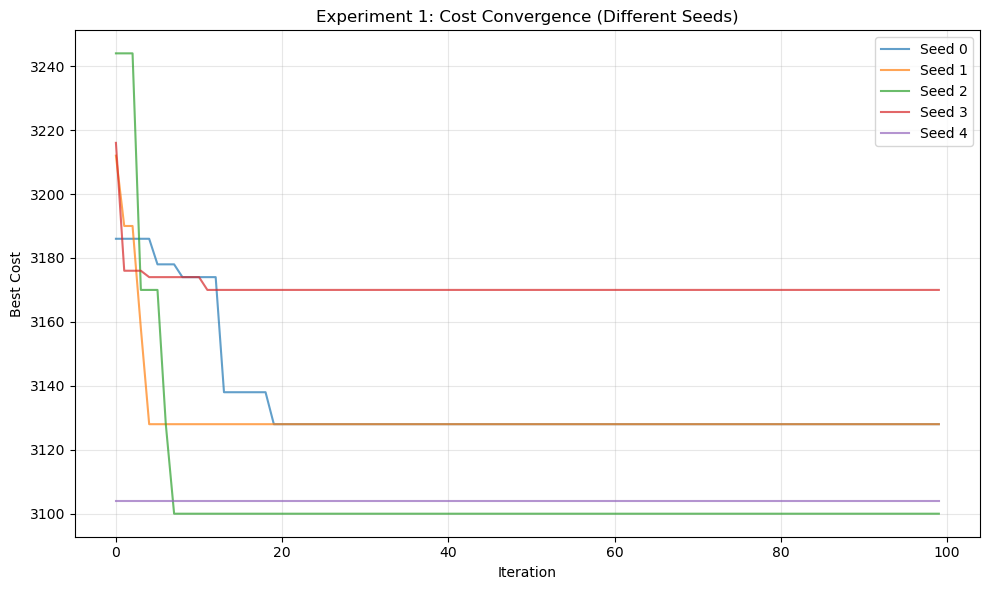

In [3]:
print("\n" + "="*60)
print("EXPERIMENT 1: Multiple runs with different seeds")
print("="*60)

exp1_results = []
exp1_histories = []

for seed in range(5):
    print(f"\nRun {seed + 1} (seed={seed}):")
    best_assignment, best_cost, cost_history = aco_qap(
        flow_matrix, distance_matrix, 
        num_ants=20, alpha=1.0, beta=2.0, rho=0.1, Q=100, 
        iterations=100, seed=seed
    )
    exp1_results.append(best_cost)
    exp1_histories.append(cost_history)
    print(f"  Best cost: {best_cost}")

average_cost = np.mean(exp1_results)
print(f"\nAverage best cost across 5 runs: {average_cost:.2f}")
print(f"Best individual cost: {min(exp1_results)}")
print(f"Known optimal: 2570")

# Plot convergence
plt.figure(figsize=(10, 6))
for i, history in enumerate(exp1_histories):
    plt.plot(history, label=f'Seed {i}', alpha=0.7)
plt.xlabel('Iteration')
plt.ylabel('Best Cost')
plt.title('Experiment 1: Cost Convergence (Different Seeds)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [4]:
print("\n" + "="*60)
print("EXPERIMENT 2: Different population sizes")
print("="*60)

population_sizes = [10, 20, 50, 100]
exp2_results = {}

for pop_size in population_sizes:
    print(f"\nPopulation size: {pop_size}")
    costs = []
    
    for seed in range(5):
        best_assignment, best_cost, cost_history = aco_qap(
            flow_matrix, distance_matrix,
            num_ants=pop_size, alpha=1.0, beta=2.0, rho=0.1, Q=100,
            iterations=100, seed=seed
        )
        costs.append(best_cost)
    
    avg_cost = np.mean(costs)
    exp2_results[pop_size] = avg_cost
    print(f"  Average cost: {avg_cost:.2f}, Best: {min(costs)}")

print("\nSummary - Population Size Results:")
for pop_size, avg_cost in exp2_results.items():
    print(f"  Population {pop_size}: {avg_cost:.2f}")


EXPERIMENT 2: Different population sizes

Population size: 10
  Average cost: 3138.00, Best: 3104

Population size: 20
  Average cost: 3126.00, Best: 3100

Population size: 50
  Average cost: 3080.00, Best: 2984

Population size: 100
  Average cost: 3075.60, Best: 2978

Summary - Population Size Results:
  Population 10: 3138.00
  Population 20: 3126.00
  Population 50: 3080.00
  Population 100: 3075.60


In [5]:
print("\n" + "="*60)
print("EXPERIMENT 3: Different initial pheromone amounts")
print("="*60)

# Modified ACO to accept initial pheromone parameter
def aco_qap_with_init_pheromone(flow, distance, num_ants=20, alpha=1.0, beta=2.0, 
                                 rho=0.1, Q=100, iterations=100, seed=None, 
                                 init_pheromone=1.0):
    """ACO with configurable initial pheromone amount."""
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)
    
    n = len(flow)
    pheromone = np.ones((n, n)) * init_pheromone
    heuristic = 1.0 / (distance + 1.0)
    
    best_assignment = None
    best_cost = float('inf')
    cost_history = []
    
    for iteration in range(iterations):
        ant_assignments = []
        ant_costs = []
        
        for ant in range(num_ants):
            assignment = []
            available_locations = list(range(n))
            
            for facility in range(n):
                if len(available_locations) == 1:
                    chosen_location = available_locations[0]
                else:
                    probabilities = []
                    for location in available_locations:
                        tau = pheromone[facility][location] ** alpha
                        eta = heuristic[facility][location] ** beta
                        prob = tau * eta
                        probabilities.append(prob)
                    
                    total_prob = sum(probabilities)
                    if total_prob > 0:
                        probabilities = [p / total_prob for p in probabilities]
                    else:
                        probabilities = [1.0 / len(available_locations)] * len(available_locations)
                    
                    chosen_location = np.random.choice(available_locations, p=probabilities)
                
                assignment.append(chosen_location)
                available_locations.remove(chosen_location)
            
            cost = calculate_cost(assignment, flow, distance)
            ant_assignments.append(assignment)
            ant_costs.append(cost)
            
            if cost < best_cost:
                best_cost = cost
                best_assignment = assignment.copy()
        
        pheromone = pheromone * (1 - rho)
        
        for ant_idx in range(num_ants):
            assignment = ant_assignments[ant_idx]
            cost = ant_costs[ant_idx]
            if cost > 0:
                deposit = Q / cost
                
                for facility in range(n):
                    location = assignment[facility]
                    pheromone[facility][location] += deposit
        
        cost_history.append(best_cost)
    
    return best_assignment, best_cost, cost_history

pheromone_amounts = [0.1, 1.0, 10.0]
exp3_results = {}

for init_pher in pheromone_amounts:
    print(f"\nInitial pheromone: {init_pher}")
    costs = []
    
    for seed in range(5):
        best_assignment, best_cost, cost_history = aco_qap_with_init_pheromone(
            flow_matrix, distance_matrix,
            num_ants=20, alpha=1.0, beta=2.0, rho=0.1, Q=100,
            iterations=100, seed=seed, init_pheromone=init_pher
        )
        costs.append(best_cost)
    
    avg_cost = np.mean(costs)
    exp3_results[init_pher] = avg_cost
    print(f"  Average cost: {avg_cost:.2f}, Best: {min(costs)}")

print("\nSummary - Initial Pheromone Results:")
for init_pher, avg_cost in exp3_results.items():
    print(f"  Init Pheromone {init_pher}: {avg_cost:.2f}")


EXPERIMENT 3: Different initial pheromone amounts

Initial pheromone: 0.1
  Average cost: 3131.20, Best: 3104

Initial pheromone: 1.0
  Average cost: 3126.00, Best: 3100

Initial pheromone: 10.0
  Average cost: 3076.40, Best: 3030

Summary - Initial Pheromone Results:
  Init Pheromone 0.1: 3131.20
  Init Pheromone 1.0: 3126.00
  Init Pheromone 10.0: 3076.40


In [6]:
print("\n" + "="*60)
print("EXPERIMENT 4: Different alpha and beta combinations")
print("="*60)

alpha_beta_pairs = [(1, 2), (2, 3), (1, 5), (2, 1), (3, 2), (5, 1)]
exp4_results = {}

for alpha_val, beta_val in alpha_beta_pairs:
    print(f"\nAlpha={alpha_val}, Beta={beta_val}:")
    costs = []
    
    for seed in range(5):
        best_assignment, best_cost, cost_history = aco_qap(
            flow_matrix, distance_matrix,
            num_ants=20, alpha=alpha_val, beta=beta_val, rho=0.1, Q=100,
            iterations=100, seed=seed
        )
        costs.append(best_cost)
    
    avg_cost = np.mean(costs)
    exp4_results[(alpha_val, beta_val)] = avg_cost
    print(f"  Average cost: {avg_cost:.2f}, Best: {min(costs)}")

print("\nSummary - Alpha/Beta Results:")
best_pair = min(exp4_results.items(), key=lambda x: x[1])
for (alpha_val, beta_val), avg_cost in exp4_results.items():
    print(f"  Alpha={alpha_val}, Beta={beta_val}: {avg_cost:.2f}")
print(f"\nBest performing pair: Alpha={best_pair[0][0]}, Beta={best_pair[0][1]} with avg cost {best_pair[1]:.2f}")


EXPERIMENT 4: Different alpha and beta combinations

Alpha=1, Beta=2:
  Average cost: 3126.00, Best: 3100

Alpha=2, Beta=3:
  Average cost: 3203.20, Best: 3114

Alpha=1, Beta=5:
  Average cost: 3253.20, Best: 3246

Alpha=2, Beta=1:
  Average cost: 3082.80, Best: 2962

Alpha=3, Beta=2:
  Average cost: 3152.40, Best: 3104

Alpha=5, Beta=1:
  Average cost: 3109.60, Best: 3082

Summary - Alpha/Beta Results:
  Alpha=1, Beta=2: 3126.00
  Alpha=2, Beta=3: 3203.20
  Alpha=1, Beta=5: 3253.20
  Alpha=2, Beta=1: 3082.80
  Alpha=3, Beta=2: 3152.40
  Alpha=5, Beta=1: 3109.60

Best performing pair: Alpha=2, Beta=1 with avg cost 3082.80


In [7]:
print("\n" + "="*60)
print("EXPERIMENT 5: Heuristic-only search (alpha=0)")
print("="*60)

exp5_results = []

for seed in range(5):
    print(f"\nRun {seed + 1} (seed={seed}):")
    best_assignment, best_cost, cost_history = aco_qap(
        flow_matrix, distance_matrix,
        num_ants=20, alpha=0.0, beta=2.0, rho=0.1, Q=100,
        iterations=100, seed=seed
    )
    exp5_results.append(best_cost)
    print(f"  Best cost: {best_cost}")

avg_cost = np.mean(exp5_results)
print(f"\nAverage cost (alpha=0): {avg_cost:.2f}")
print(f"Best cost (alpha=0): {min(exp5_results)}")
print(f"Compare to Experiment 1 average: {np.mean(exp1_results):.2f}")


EXPERIMENT 5: Heuristic-only search (alpha=0)

Run 1 (seed=0):
  Best cost: 3048

Run 2 (seed=1):
  Best cost: 3002

Run 3 (seed=2):
  Best cost: 2982

Run 4 (seed=3):
  Best cost: 3026

Run 5 (seed=4):
  Best cost: 3020

Average cost (alpha=0): 3015.60
Best cost (alpha=0): 2982
Compare to Experiment 1 average: 3126.00


In [8]:
print("\n" + "="*60)
print("EXPERIMENT 6: Pheromone-only search (beta=0)")
print("="*60)

exp6_results = []

for seed in range(5):
    print(f"\nRun {seed + 1} (seed={seed}):")
    best_assignment, best_cost, cost_history = aco_qap(
        flow_matrix, distance_matrix,
        num_ants=20, alpha=1.0, beta=0.0, rho=0.1, Q=100,
        iterations=100, seed=seed
    )
    exp6_results.append(best_cost)
    print(f"  Best cost: {best_cost}")

avg_cost = np.mean(exp6_results)
print(f"\nAverage cost (beta=0): {avg_cost:.2f}")
print(f"Best cost (beta=0): {min(exp6_results)}")
print(f"Compare to Experiment 1 average: {np.mean(exp1_results):.2f}")


EXPERIMENT 6: Pheromone-only search (beta=0)

Run 1 (seed=0):
  Best cost: 3000

Run 2 (seed=1):
  Best cost: 2938

Run 3 (seed=2):
  Best cost: 2988

Run 4 (seed=3):
  Best cost: 2982

Run 5 (seed=4):
  Best cost: 3010

Average cost (beta=0): 2983.60
Best cost (beta=0): 2938
Compare to Experiment 1 average: 3126.00


In [9]:
print("\n" + "="*60)
print("EXPERIMENT 7: Exploration vs Exploitation with q0=0.8")
print("="*60)

def aco_qap_with_q0(flow, distance, num_ants=20, alpha=1.0, beta=2.0, rho=0.1, 
                     Q=100, iterations=100, seed=None, q0=0.8):
    """ACO with q0 parameter for balancing exploration and exploitation."""
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)
    
    n = len(flow)
    pheromone = np.ones((n, n))
    heuristic = 1.0 / (distance + 1.0)
    
    best_assignment = None
    best_cost = float('inf')
    cost_history = []
    
    for iteration in range(iterations):
        ant_assignments = []
        ant_costs = []
        
        for ant in range(num_ants):
            assignment = []
            available_locations = list(range(n))
            
            for facility in range(n):
                if len(available_locations) == 1:
                    chosen_location = available_locations[0]
                else:
                    # Exploitation vs Exploration
                    if random.random() < q0:
                        # Exploitation: choose best location
                        best_value = -1
                        best_loc = available_locations[0]
                        for location in available_locations:
                            tau = pheromone[facility][location] ** alpha
                            eta = heuristic[facility][location] ** beta
                            value = tau * eta
                            if value > best_value:
                                best_value = value
                                best_loc = location
                        chosen_location = best_loc
                    else:
                        # Exploration: probabilistic choice
                        probabilities = []
                        for location in available_locations:
                            tau = pheromone[facility][location] ** alpha
                            eta = heuristic[facility][location] ** beta
                            prob = tau * eta
                            probabilities.append(prob)
                        
                        total_prob = sum(probabilities)
                        if total_prob > 0:
                            probabilities = [p / total_prob for p in probabilities]
                        else:
                            probabilities = [1.0 / len(available_locations)] * len(available_locations)
                        
                        chosen_location = np.random.choice(available_locations, p=probabilities)
                
                assignment.append(chosen_location)
                available_locations.remove(chosen_location)
            
            cost = calculate_cost(assignment, flow, distance)
            ant_assignments.append(assignment)
            ant_costs.append(cost)
            
            if cost < best_cost:
                best_cost = cost
                best_assignment = assignment.copy()
        
        pheromone = pheromone * (1 - rho)
        
        for ant_idx in range(num_ants):
            assignment = ant_assignments[ant_idx]
            cost = ant_costs[ant_idx]
            if cost > 0:
                deposit = Q / cost
                
                for facility in range(n):
                    location = assignment[facility]
                    pheromone[facility][location] += deposit
        
        cost_history.append(best_cost)
    
    return best_assignment, best_cost, cost_history

exp7_results = []

for seed in range(5):
    print(f"\nRun {seed + 1} (seed={seed}):")
    best_assignment, best_cost, cost_history = aco_qap_with_q0(
        flow_matrix, distance_matrix,
        num_ants=20, alpha=1.0, beta=2.0, rho=0.1, Q=100,
        iterations=100, seed=seed, q0=0.8
    )
    exp7_results.append(best_cost)
    print(f"  Best cost: {best_cost}")

avg_cost = np.mean(exp7_results)
print(f"\nAverage cost (q0=0.8): {avg_cost:.2f}")
print(f"Best cost (q0=0.8): {min(exp7_results)}")
print(f"Compare to Experiment 1 average: {np.mean(exp1_results):.2f}")


EXPERIMENT 7: Exploration vs Exploitation with q0=0.8

Run 1 (seed=0):
  Best cost: 3254

Run 2 (seed=1):
  Best cost: 3190

Run 3 (seed=2):
  Best cost: 3246

Run 4 (seed=3):
  Best cost: 3234

Run 5 (seed=4):
  Best cost: 3152

Average cost (q0=0.8): 3215.20
Best cost (q0=0.8): 3152
Compare to Experiment 1 average: 3126.00


In [10]:
print("\n" + "="*60)
print("EXPERIMENT 8: Local pheromone updating")
print("="*60)

def aco_qap_local_update(flow, distance, num_ants=20, alpha=1.0, beta=2.0, 
                          rho=0.1, rho_local=0.01, Q=100, iterations=100, seed=None):
    """ACO with both local and global pheromone updates."""
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)
    
    n = len(flow)
    pheromone = np.ones((n, n))
    heuristic = 1.0 / (distance + 1.0)
    
    best_assignment = None
    best_cost = float('inf')
    cost_history = []
    
    for iteration in range(iterations):
        ant_assignments = []
        ant_costs = []
        
        for ant in range(num_ants):
            assignment = []
            available_locations = list(range(n))
            
            for facility in range(n):
                if len(available_locations) == 1:
                    chosen_location = available_locations[0]
                else:
                    probabilities = []
                    for location in available_locations:
                        tau = pheromone[facility][location] ** alpha
                        eta = heuristic[facility][location] ** beta
                        prob = tau * eta
                        probabilities.append(prob)
                    
                    total_prob = sum(probabilities)
                    if total_prob > 0:
                        probabilities = [p / total_prob for p in probabilities]
                    else:
                        probabilities = [1.0 / len(available_locations)] * len(available_locations)
                    
                    chosen_location = np.random.choice(available_locations, p=probabilities)
                
                assignment.append(chosen_location)
                available_locations.remove(chosen_location)
                
                # Local pheromone update (evaporation after each step)
                pheromone[facility][chosen_location] *= (1 - rho_local)
            
            cost = calculate_cost(assignment, flow, distance)
            ant_assignments.append(assignment)
            ant_costs.append(cost)
            
            if cost < best_cost:
                best_cost = cost
                best_assignment = assignment.copy()
        
        # Global pheromone update
        pheromone = pheromone * (1 - rho)
        
        for ant_idx in range(num_ants):
            assignment = ant_assignments[ant_idx]
            cost = ant_costs[ant_idx]
            if cost > 0:
                deposit = Q / cost
                
                for facility in range(n):
                    location = assignment[facility]
                    pheromone[facility][location] += deposit
        
        cost_history.append(best_cost)
    
    return best_assignment, best_cost, cost_history

exp8_results = []

for seed in range(5):
    print(f"\nRun {seed + 1} (seed={seed}):")
    best_assignment, best_cost, cost_history = aco_qap_local_update(
        flow_matrix, distance_matrix,
        num_ants=20, alpha=1.0, beta=2.0, rho=0.1, rho_local=0.01, Q=100,
        iterations=100, seed=seed
    )
    exp8_results.append(best_cost)
    print(f"  Best cost: {best_cost}")

avg_cost = np.mean(exp8_results)
print(f"\nAverage cost (local update): {avg_cost:.2f}")
print(f"Best cost (local update): {min(exp8_results)}")
print(f"Compare to Experiment 1 average: {np.mean(exp1_results):.2f}")


EXPERIMENT 8: Local pheromone updating

Run 1 (seed=0):
  Best cost: 3130

Run 2 (seed=1):
  Best cost: 3102

Run 3 (seed=2):
  Best cost: 3038

Run 4 (seed=3):
  Best cost: 3020

Run 5 (seed=4):
  Best cost: 3104

Average cost (local update): 3078.80
Best cost (local update): 3020
Compare to Experiment 1 average: 3126.00


In [11]:
print("\n" + "="*60)
print("EXPERIMENT 9: Elitist pheromone strategy")
print("="*60)

def aco_qap_elitist(flow, distance, num_ants=20, alpha=1.0, beta=2.0, rho=0.1, 
                     Q=100, iterations=100, seed=None, elitist_weight=2.0):
    """ACO with elitist strategy - best ant deposits extra pheromone."""
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)
    
    n = len(flow)
    pheromone = np.ones((n, n))
    heuristic = 1.0 / (distance + 1.0)
    
    best_assignment = None
    best_cost = float('inf')
    cost_history = []
    
    for iteration in range(iterations):
        ant_assignments = []
        ant_costs = []
        
        for ant in range(num_ants):
            assignment = []
            available_locations = list(range(n))
            
            for facility in range(n):
                if len(available_locations) == 1:
                    chosen_location = available_locations[0]
                else:
                    probabilities = []
                    for location in available_locations:
                        tau = pheromone[facility][location] ** alpha
                        eta = heuristic[facility][location] ** beta
                        prob = tau * eta
                        probabilities.append(prob)
                    
                    total_prob = sum(probabilities)
                    if total_prob > 0:
                        probabilities = [p / total_prob for p in probabilities]
                    else:
                        probabilities = [1.0 / len(available_locations)] * len(available_locations)
                    
                    chosen_location = np.random.choice(available_locations, p=probabilities)
                
                assignment.append(chosen_location)
                available_locations.remove(chosen_location)
            
            cost = calculate_cost(assignment, flow, distance)
            ant_assignments.append(assignment)
            ant_costs.append(cost)
            
            if cost < best_cost:
                best_cost = cost
                best_assignment = assignment.copy()
        
        # Global pheromone update
        pheromone = pheromone * (1 - rho)
        
        # Regular pheromone deposit by all ants
        for ant_idx in range(num_ants):
            assignment = ant_assignments[ant_idx]
            cost = ant_costs[ant_idx]
            if cost > 0:
                deposit = Q / cost
                
                for facility in range(n):
                    location = assignment[facility]
                    pheromone[facility][location] += deposit
        
        # Elitist deposit: best ant deposits extra pheromone
        best_iteration_idx = np.argmin(ant_costs)
        best_iteration_assignment = ant_assignments[best_iteration_idx]
        best_iteration_cost = ant_costs[best_iteration_idx]
        
        if best_iteration_cost > 0:
            elitist_deposit = elitist_weight * Q / best_iteration_cost
            
            for facility in range(n):
                location = best_iteration_assignment[facility]
                pheromone[facility][location] += elitist_deposit
        
        cost_history.append(best_cost)
    
    return best_assignment, best_cost, cost_history

exp9_results = []

for seed in range(5):
    print(f"\nRun {seed + 1} (seed={seed}):")
    best_assignment, best_cost, cost_history = aco_qap_elitist(
        flow_matrix, distance_matrix,
        num_ants=20, alpha=1.0, beta=2.0, rho=0.1, Q=100,
        iterations=100, seed=seed, elitist_weight=2.0
    )
    exp9_results.append(best_cost)
    print(f"  Best cost: {best_cost}")

avg_cost = np.mean(exp9_results)
print(f"\nAverage cost (elitist): {avg_cost:.2f}")
print(f"Best cost (elitist): {min(exp9_results)}")
print(f"Compare to Experiment 1 average: {np.mean(exp1_results):.2f}")



EXPERIMENT 9: Elitist pheromone strategy

Run 1 (seed=0):
  Best cost: 3058

Run 2 (seed=1):
  Best cost: 3128

Run 3 (seed=2):
  Best cost: 3064

Run 4 (seed=3):
  Best cost: 3078

Run 5 (seed=4):
  Best cost: 3100

Average cost (elitist): 3085.60
Best cost (elitist): 3058
Compare to Experiment 1 average: 3126.00


In [12]:
print("\n" + "="*60)
print("SUMMARY TABLE: ALL EXPERIMENTS")
print("="*60)

# Collect all results
summary_data = [
    ("Exp 1: Baseline (5 seeds)", np.mean(exp1_results), min(exp1_results)),
    ("Exp 2: Pop=10", exp2_results[10], None),
    ("Exp 2: Pop=20", exp2_results[20], None),
    ("Exp 2: Pop=50", exp2_results[50], None),
    ("Exp 2: Pop=100", exp2_results[100], None),
    ("Exp 3: Init Pher=0.1", exp3_results[0.1], None),
    ("Exp 3: Init Pher=1.0", exp3_results[1.0], None),
    ("Exp 3: Init Pher=10.0", exp3_results[10.0], None),
    ("Exp 4: α=1,β=2", exp4_results[(1,2)], None),
    ("Exp 4: α=2,β=3", exp4_results[(2,3)], None),
    ("Exp 4: α=1,β=5", exp4_results[(1,5)], None),
    ("Exp 4: α=2,β=1", exp4_results[(2,1)], None),
    ("Exp 4: α=3,β=2", exp4_results[(3,2)], None),
    ("Exp 4: α=5,β=1", exp4_results[(5,1)], None),
    ("Exp 5: α=0 (heuristic only)", np.mean(exp5_results), min(exp5_results)),
    ("Exp 6: β=0 (pheromone only)", np.mean(exp6_results), min(exp6_results)),
    ("Exp 7: q0=0.8", np.mean(exp7_results), min(exp7_results)),
    ("Exp 8: Local update", np.mean(exp8_results), min(exp8_results)),
    ("Exp 9: Elitist strategy", np.mean(exp9_results), min(exp9_results)),
]

print(f"\n{'Experiment':<35} {'Avg Cost':<12} {'Best Cost':<12}")
print("-" * 60)
for exp_name, avg_cost, best_cost in summary_data:
    if best_cost is not None:
        print(f"{exp_name:<35} {avg_cost:>10.2f}   {best_cost:>10.2f}")
    else:
        print(f"{exp_name:<35} {avg_cost:>10.2f}   {'N/A':>10}")

print("\n" + "="*60)
print(f"Known optimal cost: 2570")
print("="*60)

# Find overall best result
all_individual_results = (exp1_results + exp5_results + exp6_results + 
                          exp7_results + exp8_results + exp9_results)
overall_best = min(all_individual_results)
print(f"\nOverall best cost found: {overall_best}")


SUMMARY TABLE: ALL EXPERIMENTS

Experiment                          Avg Cost     Best Cost   
------------------------------------------------------------
Exp 1: Baseline (5 seeds)              3126.00      3100.00
Exp 2: Pop=10                          3138.00          N/A
Exp 2: Pop=20                          3126.00          N/A
Exp 2: Pop=50                          3080.00          N/A
Exp 2: Pop=100                         3075.60          N/A
Exp 3: Init Pher=0.1                   3131.20          N/A
Exp 3: Init Pher=1.0                   3126.00          N/A
Exp 3: Init Pher=10.0                  3076.40          N/A
Exp 4: α=1,β=2                         3126.00          N/A
Exp 4: α=2,β=3                         3203.20          N/A
Exp 4: α=1,β=5                         3253.20          N/A
Exp 4: α=2,β=1                         3082.80          N/A
Exp 4: α=3,β=2                         3152.40          N/A
Exp 4: α=5,β=1                         3109.60          N/A
Exp 

In [13]:
# Orienteering Problem: Define problem data

print("\n" + "="*60)
print("SECTION 2: ORIENTEERING PROBLEM")
print("="*60)

# Problem parameters from homework
Tmax = 55  # Maximum travel distance
P = 1      # Number of paths

# City data from homework: (x, y, score)
# City 0 is starting point, City 1 is ending point (but we use 0 for both in our implementation)
cities_data = {
    0: (19.1, 24.3, 0),   # Starting point
    1: (18.2, 24.0, 0),   # Ending point (we'll use city 0 as depot for simplicity)
    2: (12.6, 24.9, 20),
    3: (14.4, 28.0, 20),
    4: (16.9, 28.1, 20),
    5: (20.7, 28.2, 20),
    6: (12.5, 26.6, 20),
    7: (21.8, 27.3, 20),
    8: (12.5, 22.6, 20),
    9: (22.5, 17.0, 30),
    10: (19.9, 15.0, 30),
    11: (14.9, 15.1, 30),
    12: (11.5, 18.6, 30),
    13: (12.4, 29.8, 30),
    14: (17.8, 28.1, 30),
    15: (9.1, 29.8, 40),
    16: (10.0, 32.6, 40),
    17: (13.9, 33.1, 40),
    18: (19.95, 10.3, 40),
    19: (15.2, 8.0, 40),
    20: (14.7, 31.2, 50),
    21: (7.4, 36.5, 50),
    22: (21.0, 25.5, 50),
    23: (18.0, 25.3, 10),
    24: (19.5, 24.7, 10),
    25: (21.4, 21.8, 10),
    26: (16.0, 21.4, 10),
    27: (18.65, 26.2, 10),
    28: (17.9, 28.9, 10),
    29: (14.3, 19.9, 20),
    30: (17.0, 19.0, 20),
    31: (10.80, 21.0, 20),
    32: (15.7, 23.7, 10),
}

num_cities = len(cities_data)

# Extract coordinates and scores
city_coords = np.array([cities_data[i][:2] for i in range(num_cities)])
city_scores = np.array([cities_data[i][2] for i in range(num_cities)])

# Function to calculate Euclidean distance
def euclidean_distance(city1, city2):
    """Calculate Euclidean distance between two cities."""
    x1, y1 = city_coords[city1]
    x2, y2 = city_coords[city2]
    return np.sqrt((x2 - x1)**2 + (y2 - y1)**2)

# Create distance matrix for all city pairs
distance_matrix_op = np.zeros((num_cities, num_cities))
for i in range(num_cities):
    for j in range(num_cities):
        distance_matrix_op[i][j] = euclidean_distance(i, j)

# Function to calculate total distance of a route
def calculate_route_distance(route):
    """Calculate total distance of a route."""
    total_dist = 0
    for i in range(len(route) - 1):
        total_dist += distance_matrix_op[route[i]][route[i+1]]
    return total_dist

# Function to calculate total score of a route
def calculate_route_score(route):
    """Calculate total score of a route (excluding start/end depot)."""
    total_score = 0
    for city in route:
        if city != 0:  # Don't count depot
            total_score += city_scores[city]
    return total_score

print(f"Orienteering Problem initialized:")
print(f"  Number of cities: {num_cities}")
print(f"  Maximum distance (Tmax): {Tmax}")
print(f"  Start/End city: 0 (depot)")
print(f"  Known best solution: 550")


SECTION 2: ORIENTEERING PROBLEM
Orienteering Problem initialized:
  Number of cities: 33
  Maximum distance (Tmax): 55
  Start/End city: 0 (depot)
  Known best solution: 550


In [14]:
print("\n" + "="*60)
print("ACO FOR ORIENTEERING PROBLEM")
print("="*60)

def aco_orienteering(distance_matrix, scores, Tmax, num_ants=20, alpha=1.0, 
                     beta=2.0, rho=0.1, Q=100, iterations=100, seed=None,
                     use_local_update=False, use_elitist=False, q0=None):
    """
    ACO for Orienteering Problem.
    
    Goal: Maximize score while keeping total distance <= Tmax.
    Route must start and end at city 0 (depot).
    """
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)
    
    n = len(scores)
    
    # Initialize pheromone matrix
    pheromone = np.ones((n, n))
    
    # Heuristic: score / distance (prefer high score, short distance)
    heuristic = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i != j and distance_matrix[i][j] > 0:
                heuristic[i][j] = (scores[j] + 1.0) / (distance_matrix[i][j] + 1.0)
    
    best_route = None
    best_score = 0
    best_distance = 0
    
    for iteration in range(iterations):
        ant_routes = []
        ant_scores = []
        ant_distances = []
        
        for ant in range(num_ants):
            # Build route starting from depot (city 0)
            route = [0]
            visited = {0}
            current_city = 0
            total_distance = 0
            
            while True:
                # Find feasible next cities
                feasible_cities = []
                for city in range(n):
                    if city not in visited:
                        # Check if we can visit this city and return to depot
                        dist_to_city = distance_matrix[current_city][city]
                        dist_to_depot = distance_matrix[city][0]
                        if total_distance + dist_to_city + dist_to_depot <= Tmax:
                            feasible_cities.append(city)
                
                if not feasible_cities:
                    # No more feasible cities, return to depot
                    break
                
                # Choose next city
                if q0 is not None and random.random() < q0:
                    # Exploitation: choose best city
                    best_value = -1
                    next_city = feasible_cities[0]
                    for city in feasible_cities:
                        tau = pheromone[current_city][city] ** alpha
                        eta = heuristic[current_city][city] ** beta
                        value = tau * eta
                        if value > best_value:
                            best_value = value
                            next_city = city
                else:
                    # Probabilistic selection
                    probabilities = []
                    for city in feasible_cities:
                        tau = pheromone[current_city][city] ** alpha
                        eta = heuristic[current_city][city] ** beta
                        prob = tau * eta
                        probabilities.append(prob)
                    
                    total_prob = sum(probabilities)
                    if total_prob > 0:
                        probabilities = [p / total_prob for p in probabilities]
                    else:
                        probabilities = [1.0 / len(feasible_cities)] * len(feasible_cities)
                    
                    next_city = np.random.choice(feasible_cities, p=probabilities)
                
                # Move to next city
                total_distance += distance_matrix[current_city][next_city]
                route.append(next_city)
                visited.add(next_city)
                current_city = next_city
                
                # Local pheromone update if enabled
                if use_local_update:
                    pheromone[route[-2]][route[-1]] *= 0.99
            
            # Return to depot
            route.append(0)
            total_distance += distance_matrix[current_city][0]
            
            # Calculate score (exclude depot)
            total_score = calculate_route_score(route)
            
            ant_routes.append(route)
            ant_scores.append(total_score)
            ant_distances.append(total_distance)
            
            # Update best solution
            if total_score > best_score:
                best_score = total_score
                best_route = route.copy()
                best_distance = total_distance
        
        # Global pheromone update
        pheromone = pheromone * (1 - rho)
        
        # Deposit pheromone
        for ant_idx in range(num_ants):
            route = ant_routes[ant_idx]
            score = ant_scores[ant_idx]
            if score > 0:
                deposit = Q * score  # Reward based on score
                for i in range(len(route) - 1):
                    pheromone[route[i]][route[i+1]] += deposit
        
        # Elitist strategy if enabled
        if use_elitist and len(ant_scores) > 0:
            best_ant_idx = np.argmax(ant_scores)
            best_ant_route = ant_routes[best_ant_idx]
            best_ant_score = ant_scores[best_ant_idx]
            if best_ant_score > 0:
                elitist_deposit = 2.0 * Q * best_ant_score
                for i in range(len(best_ant_route) - 1):
                    pheromone[best_ant_route[i]][best_ant_route[i+1]] += elitist_deposit
    
    return best_route, best_score, best_distance

# Run 5 variations of ACO for Orienteering Problem
variations = [
    ("Global update only", {"alpha": 1.0, "beta": 2.0}),
    ("With local update", {"alpha": 1.0, "beta": 2.0, "use_local_update": True}),
    ("With elitist", {"alpha": 1.0, "beta": 2.0, "use_elitist": True}),
    ("With q0=0.8", {"alpha": 1.0, "beta": 2.0, "q0": 0.8}),
    ("Pheromone-only (β=0)", {"alpha": 1.0, "beta": 0.0}),
]

orienteering_results = {}

for var_name, params in variations:
    print(f"\n{var_name}:")
    print("-" * 40)
    
    var_scores = []
    var_distances = []
    var_routes = []
    
    for seed in range(5):
        route, score, distance = aco_orienteering(
            distance_matrix_op, city_scores, Tmax,
            num_ants=20, rho=0.1, Q=100,
            iterations=100, seed=seed, **params
        )
        var_scores.append(score)
        var_distances.append(distance)
        var_routes.append(route)
        print(f"  Seed {seed}: Score={score}, Distance={distance:.2f}")
    
    avg_score = np.mean(var_scores)
    best_idx = np.argmax(var_scores)
    
    orienteering_results[var_name] = {
        "avg_score": avg_score,
        "best_score": var_scores[best_idx],
        "best_distance": var_distances[best_idx],
        "best_route": var_routes[best_idx]
    }
    
    print(f"  Average score: {avg_score:.2f}")
    print(f"  Best score: {var_scores[best_idx]}")


ACO FOR ORIENTEERING PROBLEM

Global update only:
----------------------------------------
  Seed 0: Score=510, Distance=54.23
  Seed 1: Score=510, Distance=54.88
  Seed 2: Score=490, Distance=54.71
  Seed 3: Score=480, Distance=54.77
  Seed 4: Score=500, Distance=54.54
  Average score: 498.00
  Best score: 510

With local update:
----------------------------------------
  Seed 0: Score=490, Distance=54.68
  Seed 1: Score=510, Distance=54.82
  Seed 2: Score=500, Distance=54.98
  Seed 3: Score=480, Distance=54.85
  Seed 4: Score=490, Distance=54.77
  Average score: 494.00
  Best score: 510

With elitist:
----------------------------------------
  Seed 0: Score=510, Distance=53.19
  Seed 1: Score=510, Distance=54.96
  Seed 2: Score=500, Distance=54.64
  Seed 3: Score=480, Distance=54.95
  Seed 4: Score=480, Distance=54.61
  Average score: 496.00
  Best score: 510

With q0=0.8:
----------------------------------------
  Seed 0: Score=530, Distance=53.88
  Seed 1: Score=540, Distance=54.5


ORIENTEERING PROBLEM: SUMMARY

Variation                 Avg Score    Best Score   Best Distance  
-----------------------------------------------------------------
Global update only            498.00          510           54.23
With local update             494.00          510           54.82
With elitist                  496.00          510           53.19
With q0=0.8                   530.00          540           54.51
Pheromone-only (β=0)          374.00          400           54.87

BEST VARIATION: With q0=0.8
  Best Score: 540
  Distance: 54.51 (Tmax=55)
  Route: [0, 22, 7, 5, 14, 4, 20, 17, 16, 15, 13, 3, 6, 2, 8, 31, 12, 29, 30, 26, 32, 23, 0]

Known best score: 550
Our best score: 540
Gap: 10


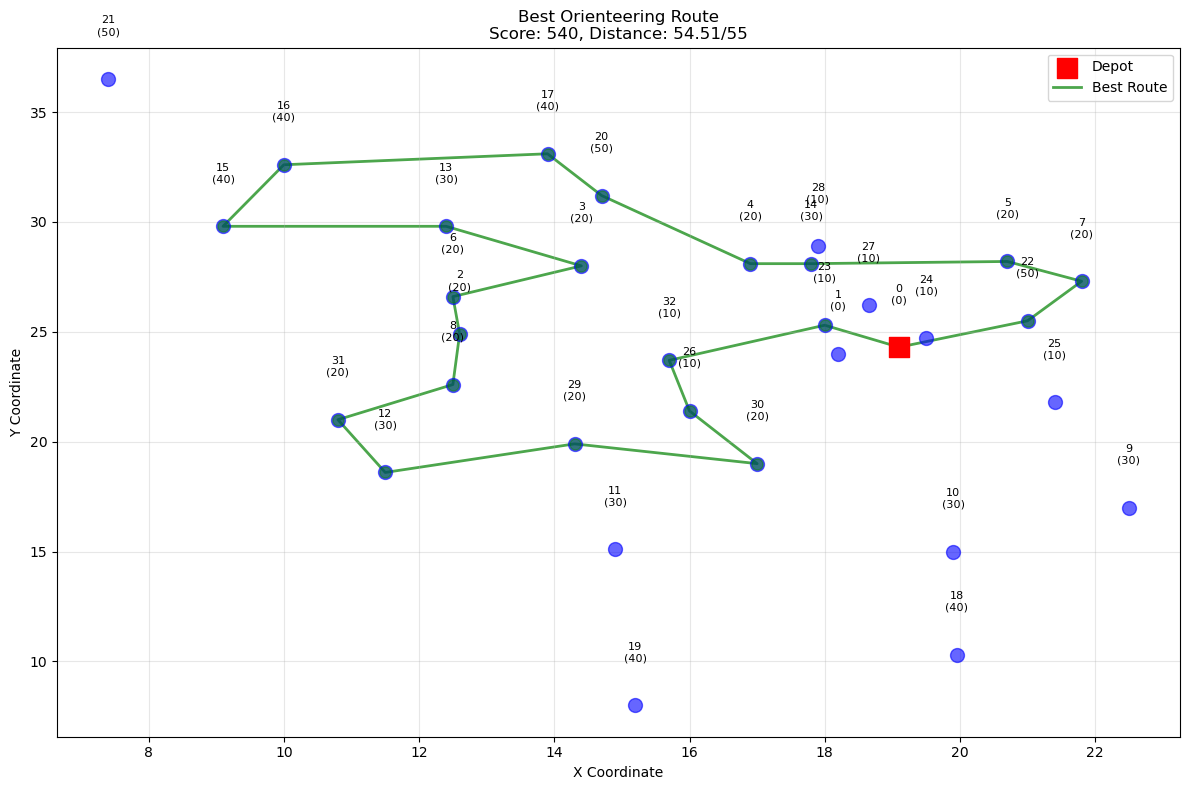


Orienteering Problem analysis complete!


In [15]:
print("\n" + "="*60)
print("ORIENTEERING PROBLEM: SUMMARY")
print("="*60)

# Find best variation
best_variation = max(orienteering_results.items(), 
                     key=lambda x: x[1]["best_score"])

print(f"\n{'Variation':<25} {'Avg Score':<12} {'Best Score':<12} {'Best Distance':<15}")
print("-" * 65)
for var_name, results in orienteering_results.items():
    print(f"{var_name:<25} {results['avg_score']:>10.2f}   "
          f"{results['best_score']:>10}   {results['best_distance']:>13.2f}")

print("\n" + "="*60)
print(f"BEST VARIATION: {best_variation[0]}")
print(f"  Best Score: {best_variation[1]['best_score']}")
print(f"  Distance: {best_variation[1]['best_distance']:.2f} (Tmax={Tmax})")
print(f"  Route: {best_variation[1]['best_route']}")
print(f"\nKnown best score: 550")
print(f"Our best score: {best_variation[1]['best_score']}")
print(f"Gap: {550 - best_variation[1]['best_score']}")
print("="*60)

# Visualize best route
best_route = best_variation[1]['best_route']
route_x = [city_coords[city][0] for city in best_route]
route_y = [city_coords[city][1] for city in best_route]

plt.figure(figsize=(12, 8))
# Plot all cities
for i in range(num_cities):
    if i == 0:
        plt.scatter(city_coords[i][0], city_coords[i][1], 
                   c='red', s=200, marker='s', label='Depot', zorder=3)
    else:
        plt.scatter(city_coords[i][0], city_coords[i][1], 
                   c='blue', s=100, alpha=0.6, zorder=2)
    plt.text(city_coords[i][0], city_coords[i][1] + 2, 
            f'{i}\n({city_scores[i]})', ha='center', fontsize=8)

# Plot best route
plt.plot(route_x, route_y, 'g-', linewidth=2, alpha=0.7, label='Best Route', zorder=1)
plt.plot(route_x, route_y, 'go', markersize=8, alpha=0.5, zorder=2)

plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.title(f'Best Orienteering Route\nScore: {best_variation[1]["best_score"]}, '
          f'Distance: {best_variation[1]["best_distance"]:.2f}/{Tmax}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nOrienteering Problem analysis complete!")